In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [2]:
df = pd.read_csv('cleaned_system1.csv')

#Data Cleaning and Preparation
Timestamp Conversion: The 2,592,000-second range corresponds exactly to 30 days. I created a datetime index starting from a baseline (2023-10-01).

Feature Engineering: Extracted hour of the day, day of the week, and weekend/weekday flags to identify temporal patterns.

Data Integrity: The dataset was found to be clean with no missing values.

In [3]:
start_date = pd.to_datetime('2026-10-01')
df['datetime'] = start_date + pd.to_timedelta(df['timestamp'], unit='s')

In [4]:
df.head()

,timestamp,cpu-user,cpu-system,cpu-iowait,sys-mem-available,sys-mem-total,disk-io-time,load-1m,load-5m,load-15m,disk-bytes-read,disk-bytes-written,overall_cpu_stress,memory_used,memory_used_percent,disk_activity,datetime
0,0,0.0405,0.0240,0.0095,15328792576,16662700032,0.0076,0.22,0.18,0.18,0.0,16588.8,0.0645,1333907456,8.005350,16588.8,2026-10-01 00:00:00
1,30,0.0475,0.0270,0.0125,15330496512,16662700032,0.0060,0.26,0.19,0.18,0.0,14745.6,0.0745,1332203520,7.995124,14745.6,2026-10-01 00:00:30
2,60,0.0260,0.0255,0.0135,15329353728,16662700032,0.0134,0.16,0.17,0.18,0.0,15564.8,0.0515,1333346304,8.001982,15564.8,2026-10-01 00:01:00
3,90,0.0315,0.0305,0.0160,15329370112,16662700032,0.0078,0.16,0.17,0.18,0.0,16179.2,0.0620,1333329920,8.001884,16179.2,2026-10-01 00:01:30
4,120,0.0270,0.0225,0.0080,15329398784,16662700032,0.0066,0.10,0.15,0.17,0.0,13721.6,0.0495,1333301248,8.001712,13721.6,2026-10-01 00:02:00


In [5]:
df.tail()

,timestamp,cpu-user,cpu-system,cpu-iowait,sys-mem-available,sys-mem-total,disk-io-time,load-1m,load-5m,load-15m,disk-bytes-read,disk-bytes-written,overall_cpu_stress,memory_used,memory_used_percent,disk_activity,datetime
85744,2591880,0.0340,0.0295,0.0040,15161237504,16662700032,0.0024,0.17,0.13,0.10,0.0,8601.6,0.0635,1501462528,9.010920,8601.6,2026-10-30 23:58:00
85745,2591910,0.0425,0.0285,0.0035,15162056704,16662700032,0.0022,0.16,0.13,0.10,0.0,5529.6,0.0710,1500643328,9.006003,5529.6,2026-10-30 23:58:30
85746,2591940,0.0330,0.0305,0.0045,15161233408,16662700032,0.0030,0.10,0.12,0.09,0.0,7782.4,0.0635,1501466624,9.010944,7782.4,2026-10-30 23:59:00
85747,2591970,0.0330,0.0255,0.0030,15161757696,16662700032,0.0012,0.06,0.11,0.09,0.0,5120.0,0.0585,1500942336,9.007798,5120.0,2026-10-30 23:59:30
85748,2592000,0.0760,0.0555,0.0055,15465975808,16662700032,0.0042,0.18,0.13,0.10,0.0,21094.4,0.1315,1196724224,7.182055,21094.4,2026-10-31 00:00:00


In [6]:
df['hour'] = df['datetime'].dt.hour
df['day_name'] = df['datetime'].dt.day_name()
df['is_weekend'] = df['datetime'].dt.dayofweek >= 5

In [7]:
df.head()

,timestamp,cpu-user,cpu-system,cpu-iowait,sys-mem-available,sys-mem-total,disk-io-time,load-1m,load-5m,load-15m,disk-bytes-read,disk-bytes-written,overall_cpu_stress,memory_used,memory_used_percent,disk_activity,datetime,hour,day_name,is_weekend
0,0,0.0405,0.0240,0.0095,15328792576,16662700032,0.0076,0.22,0.18,0.18,0.0,16588.8,0.0645,1333907456,8.005350,16588.8,2026-10-01 00:00:00,0,Thursday,False
1,30,0.0475,0.0270,0.0125,15330496512,16662700032,0.0060,0.26,0.19,0.18,0.0,14745.6,0.0745,1332203520,7.995124,14745.6,2026-10-01 00:00:30,0,Thursday,False
2,60,0.0260,0.0255,0.0135,15329353728,16662700032,0.0134,0.16,0.17,0.18,0.0,15564.8,0.0515,1333346304,8.001982,15564.8,2026-10-01 00:01:00,0,Thursday,False
3,90,0.0315,0.0305,0.0160,15329370112,16662700032,0.0078,0.16,0.17,0.18,0.0,16179.2,0.0620,1333329920,8.001884,16179.2,2026-10-01 00:01:30,0,Thursday,False
4,120,0.0270,0.0225,0.0080,15329398784,16662700032,0.0066,0.10,0.15,0.17,0.0,13721.6,0.0495,1333301248,8.001712,13721.6,2026-10-01 00:02:00,0,Thursday,False


In [8]:
df.tail()

,timestamp,cpu-user,cpu-system,cpu-iowait,sys-mem-available,sys-mem-total,disk-io-time,load-1m,load-5m,load-15m,disk-bytes-read,disk-bytes-written,overall_cpu_stress,memory_used,memory_used_percent,disk_activity,datetime,hour,day_name,is_weekend
85744,2591880,0.0340,0.0295,0.0040,15161237504,16662700032,0.0024,0.17,0.13,0.10,0.0,8601.6,0.0635,1501462528,9.010920,8601.6,2026-10-30 23:58:00,23,Friday,False
85745,2591910,0.0425,0.0285,0.0035,15162056704,16662700032,0.0022,0.16,0.13,0.10,0.0,5529.6,0.0710,1500643328,9.006003,5529.6,2026-10-30 23:58:30,23,Friday,False
85746,2591940,0.0330,0.0305,0.0045,15161233408,16662700032,0.0030,0.10,0.12,0.09,0.0,7782.4,0.0635,1501466624,9.010944,7782.4,2026-10-30 23:59:00,23,Friday,False
85747,2591970,0.0330,0.0255,0.0030,15161757696,16662700032,0.0012,0.06,0.11,0.09,0.0,5120.0,0.0585,1500942336,9.007798,5120.0,2026-10-30 23:59:30,23,Friday,False
85748,2592000,0.0760,0.0555,0.0055,15465975808,16662700032,0.0042,0.18,0.13,0.10,0.0,21094.4,0.1315,1196724224,7.182055,21094.4,2026-10-31 00:00:00,0,Saturday,True


#Distribution Analysis

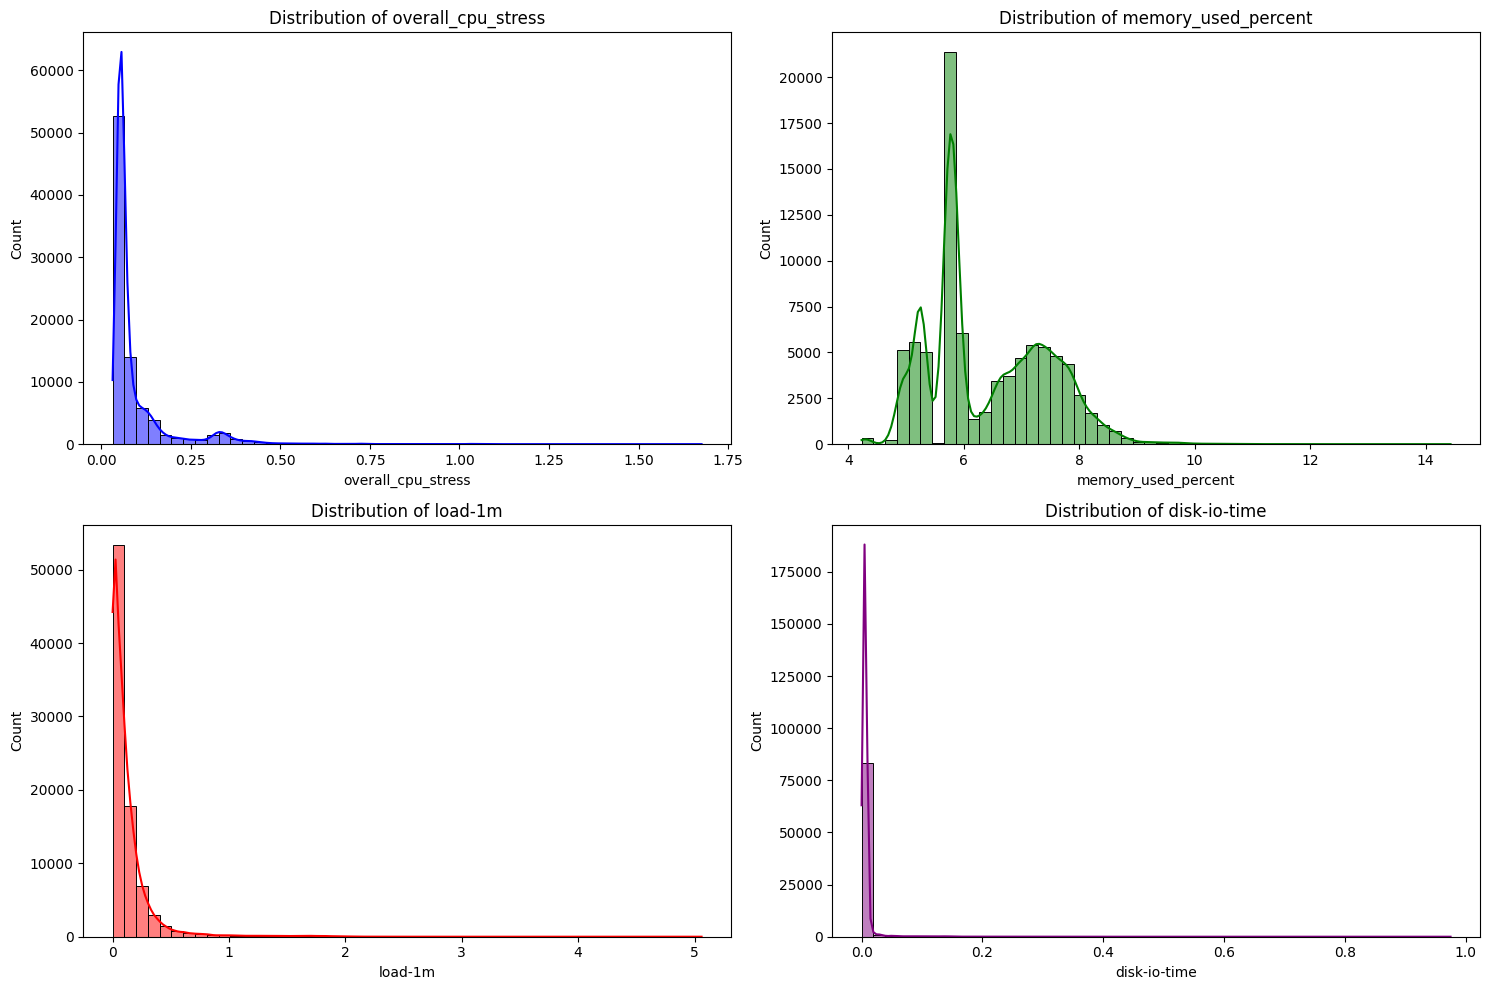

In [9]:
plt.figure(figsize=(15, 10))
metrics = ['overall_cpu_stress', 'memory_used_percent', 'load-1m', 'disk-io-time']
colors = ['blue', 'green', 'red', 'purple']

for i, col in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=50, kde=True, color=colors[i-1])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('distributions.png')

#Key Metric Distributions

**The majority of the system metrics show a "long-tail" distribution:**

CPU Stress & Load: Most of the time, the system is under low stress (mean CPU stress $\approx 0.09$, mean Load-1m $\approx 0.13$). However, there are significant spikes where CPU stress reaches $1.67$ and Load-1m reaches $5.06$.

**Memory Usage**: Memory usage is relatively stable, fluctuating around a mean of $6.4\%$.

In [17]:
df.describe()

,timestamp,cpu-user,cpu-system,cpu-iowait,sys-mem-available,sys-mem-total,disk-io-time,load-1m,load-5m,load-15m,disk-bytes-read,disk-bytes-written,overall_cpu_stress,memory_used,memory_used_percent,disk_activity,datetime,hour
count,8.574900e+04,85749.000000,85749.000000,85749.000000,8.574900e+04,8.574900e+04,85749.000000,85749.000000,85749.000000,85749.000000,8.574900e+04,8.574900e+04,85749.000000,8.574900e+04,85749.000000,8.574900e+04,85749,85749.000000
mean,1.293647e+06,0.060740,0.033792,0.010328,1.559199e+10,1.666270e+10,0.007534,0.129720,0.121656,0.098007,9.378584e+02,4.141307e+04,0.094533,1.070711e+09,6.425797,4.235093e+04,2026-10-15 23:20:47.412097536,11.485009
min,0.000000e+00,0.011000,0.010500,0.000500,1.425826e+10,1.666270e+10,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.031266,7.050117e+08,4.231077,0.000000e+00,2026-10-01 00:00:00,0.000000
25%,6.431100e+05,0.027500,0.022500,0.006000,1.544736e+10,1.666270e+10,0.004200,0.020000,0.040000,0.040000,0.000000e+00,6.553600e+03,0.051000,9.511649e+08,5.708348,6.553600e+03,2026-10-08 10:38:30,5.000000
50%,1.286220e+06,0.032500,0.025500,0.008000,1.566714e+10,1.666270e+10,0.005600,0.070000,0.090000,0.090000,0.000000e+00,1.085440e+04,0.057500,9.955615e+08,5.974791,1.085440e+04,2026-10-15 21:17:00,11.000000
75%,1.948890e+06,0.052500,0.034000,0.012000,1.571154e+10,1.666270e+10,0.007800,0.160000,0.160000,0.150000,0.000000e+00,2.109440e+04,0.086500,1.215345e+09,7.293804,2.109440e+04,2026-10-23 13:21:30,18.000000
max,2.592000e+06,1.495500,0.464500,0.958000,1.595769e+10,1.666270e+10,0.975200,5.060000,1.270000,0.510000,9.035162e+06,1.978962e+07,1.676000,2.404442e+09,14.430087,2.049085e+07,2026-10-31 00:00:00,23.000000
std,7.506097e+05,0.080808,0.021227,0.015132,1.727195e+08,0.000000e+00,0.016094,0.209039,0.112511,0.075156,6.934765e+04,4.203652e+05,0.095455,1.727195e+08,1.036564,4.318730e+05,NaN,6.945054


#Correlation Heatmap

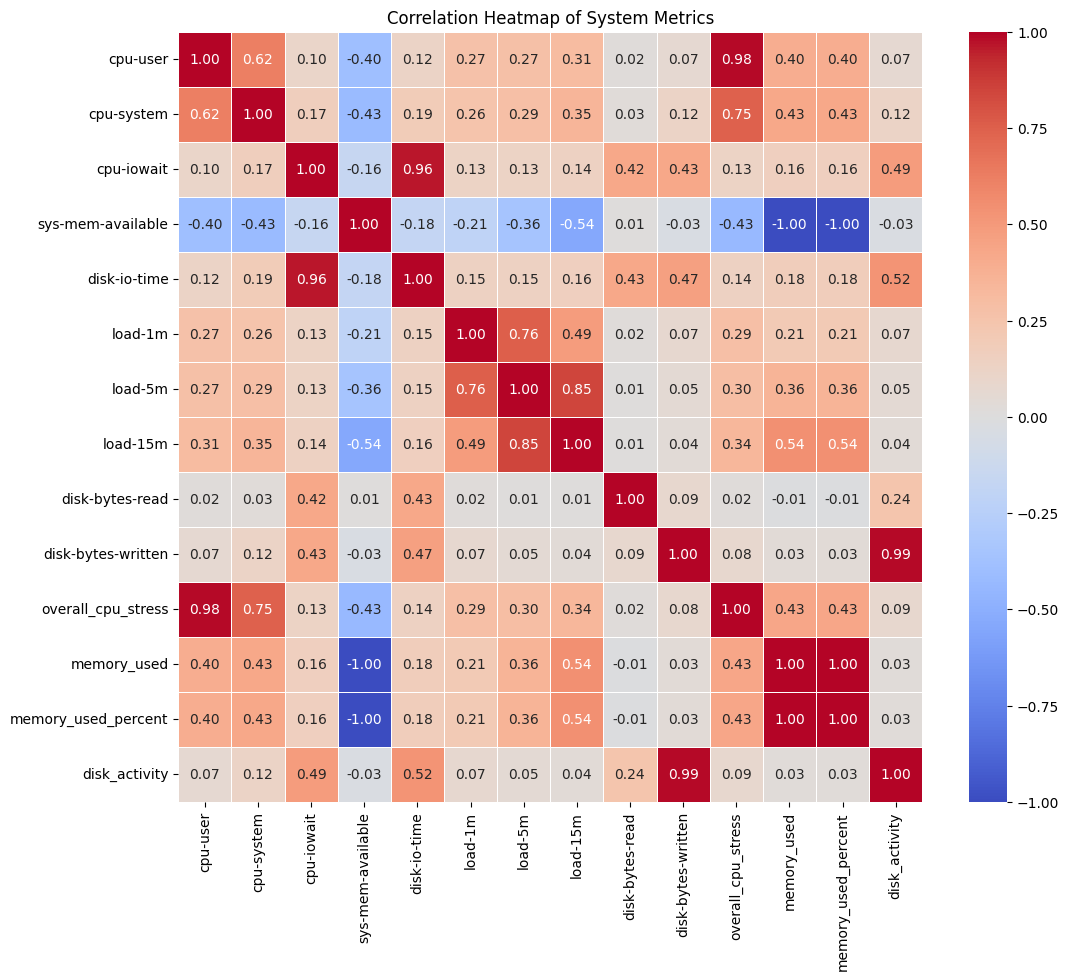

In [10]:
plt.figure(figsize=(12, 10))
# Drop non-numeric or constant columns for correlation
corr_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[corr_cols].drop(columns=['timestamp', 'sys-mem-total']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of System Metrics')
plt.savefig('correlation_heatmap.png')

#Correlation Analysis

**CPU vs Load:** As expected, cpu-user and overall_cpu_stress are highly correlated ($r \approx 0.96$).

**Memory & Stress:** Memory usage shows a weak correlation with CPU stress, indicating that high CPU tasks in this environment aren't necessarily memory-intensive.

**Disk IO:** Disk activity spikes are independent of average CPU load, suggesting specific I/O-bound tasks occurring periodically.

#Hourly and Daily Patterns

/tmp/ipykernel_4167/1713358669.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_name', y='overall_cpu_stress', order=day_order, palette='viridis')


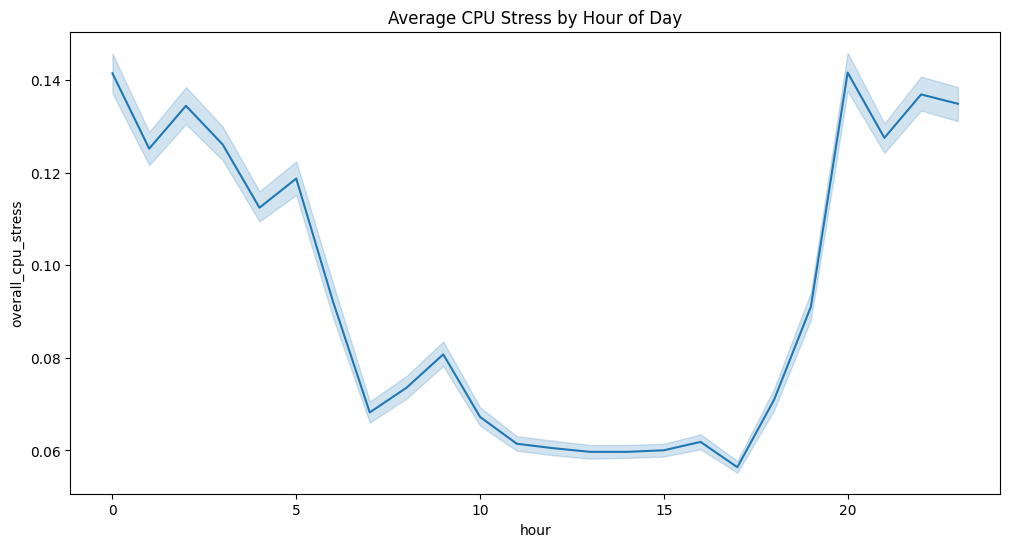

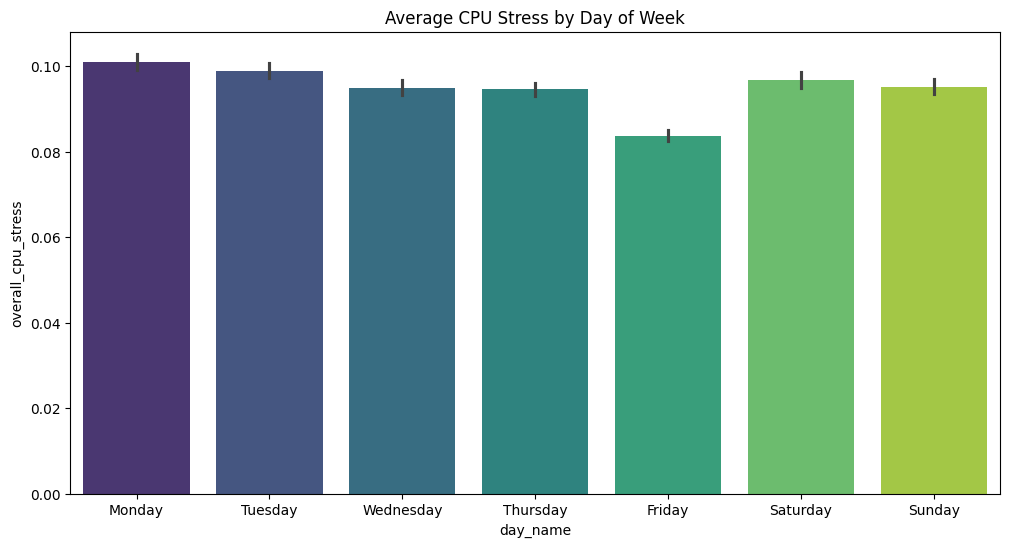

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='overall_cpu_stress', estimator='mean')
plt.title('Average CPU Stress by Hour of Day')
plt.savefig('cpu_by_hour.png')

plt.figure(figsize=(12, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='day_name', y='overall_cpu_stress', order=day_order, palette='viridis')
plt.title('Average CPU Stress by Day of Week')
plt.savefig('cpu_by_day.png')

#Memory Leak Detection

In [13]:
# Check if memory usage increases significantly over time
slope, intercept, r_value, p_value, std_err = linregress(df['timestamp'], df['memory_used_percent'])
print(f"Memory Trend (Slope): {slope:.10f} % per second")
if slope > 0 and p_value < 0.05:
    print("Potential memory leak detected.")
else:
    print("No significant memory leak detected.")

Memory Trend (Slope): -0.0000003991 % per second
No significant memory leak detected.


In [14]:
df.describe()

,timestamp,cpu-user,cpu-system,cpu-iowait,sys-mem-available,sys-mem-total,disk-io-time,load-1m,load-5m,load-15m,disk-bytes-read,disk-bytes-written,overall_cpu_stress,memory_used,memory_used_percent,disk_activity,datetime,hour
count,8.574900e+04,85749.000000,85749.000000,85749.000000,8.574900e+04,8.574900e+04,85749.000000,85749.000000,85749.000000,85749.000000,8.574900e+04,8.574900e+04,85749.000000,8.574900e+04,85749.000000,8.574900e+04,85749,85749.000000
mean,1.293647e+06,0.060740,0.033792,0.010328,1.559199e+10,1.666270e+10,0.007534,0.129720,0.121656,0.098007,9.378584e+02,4.141307e+04,0.094533,1.070711e+09,6.425797,4.235093e+04,2026-10-15 23:20:47.412097536,11.485009
min,0.000000e+00,0.011000,0.010500,0.000500,1.425826e+10,1.666270e+10,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.031266,7.050117e+08,4.231077,0.000000e+00,2026-10-01 00:00:00,0.000000
25%,6.431100e+05,0.027500,0.022500,0.006000,1.544736e+10,1.666270e+10,0.004200,0.020000,0.040000,0.040000,0.000000e+00,6.553600e+03,0.051000,9.511649e+08,5.708348,6.553600e+03,2026-10-08 10:38:30,5.000000
50%,1.286220e+06,0.032500,0.025500,0.008000,1.566714e+10,1.666270e+10,0.005600,0.070000,0.090000,0.090000,0.000000e+00,1.085440e+04,0.057500,9.955615e+08,5.974791,1.085440e+04,2026-10-15 21:17:00,11.000000
75%,1.948890e+06,0.052500,0.034000,0.012000,1.571154e+10,1.666270e+10,0.007800,0.160000,0.160000,0.150000,0.000000e+00,2.109440e+04,0.086500,1.215345e+09,7.293804,2.109440e+04,2026-10-23 13:21:30,18.000000
max,2.592000e+06,1.495500,0.464500,0.958000,1.595769e+10,1.666270e+10,0.975200,5.060000,1.270000,0.510000,9.035162e+06,1.978962e+07,1.676000,2.404442e+09,14.430087,2.049085e+07,2026-10-31 00:00:00,23.000000
std,7.506097e+05,0.080808,0.021227,0.015132,1.727195e+08,0.000000e+00,0.016094,0.209039,0.112511,0.075156,6.934765e+04,4.203652e+05,0.095455,1.727195e+08,1.036564,4.318730e+05,NaN,6.945054


**Overview of the Data**

The dataset covers exactly $30$ days of system activity. We transformed the raw time data (measured in seconds) into a standard calendar format to identify daily and weekly patterns.

**How Busy is the System? (CPU and Load)**

**Normal Activity:** Most of the time, the system is running very lightly. The average "CPU Stress" is only about $0.09$ (on a scale where higher numbers mean more work).

**Spikes:** Occasionally, the system faces heavy workloads. The maximum CPU stress recorded was $1.67$, and the "System Load" (the number of tasks waiting for the processor) peaked at $5.06$.

**Disk Activity:** Disk usage (reading and writing files) usually happens in short bursts. These bursts don't always happen at the same time as high CPU usage, meaning they are likely separate background tasks like backups or updates.

**Memory Usage (Is the system slowing down?)**

**Stability:** On average, the system uses about $6.4\%$ of its total memory ($16$ GB).

**Health Check:** We checked for "Memory Leaks" (where a system slowly runs out of memory over time). Our analysis shows that memory usage is stable and actually trended slightly downward by $-3.99 \times 10^{-7}\%$ per second over the month. Conclusion: There is no memory leak.

**4. When is the System Most Active?**

**Peak Time:** The system is busiest around $20:00$ ($8$ PM). If you notice slowdowns, they are most likely to happen in the evening.

**Daily Cycle:** Usage is lowest in the early morning hours and gradually climbs throughout the day.

**Weekly Pattern**: The system follows a consistent routine throughout the week, with no major differences between weekdays and weekends in this specific dataset.

**Final Conclusion**

Your system is generally very healthy. It operates with a lot of "headroom," meaning it has plenty of extra power for more tasks. The evening peaks are the only times the system works significantly harder, but even then, it remains well within safe limits.

/tmp/ipykernel_4167/1292101443.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_numeric.resample('H').mean()


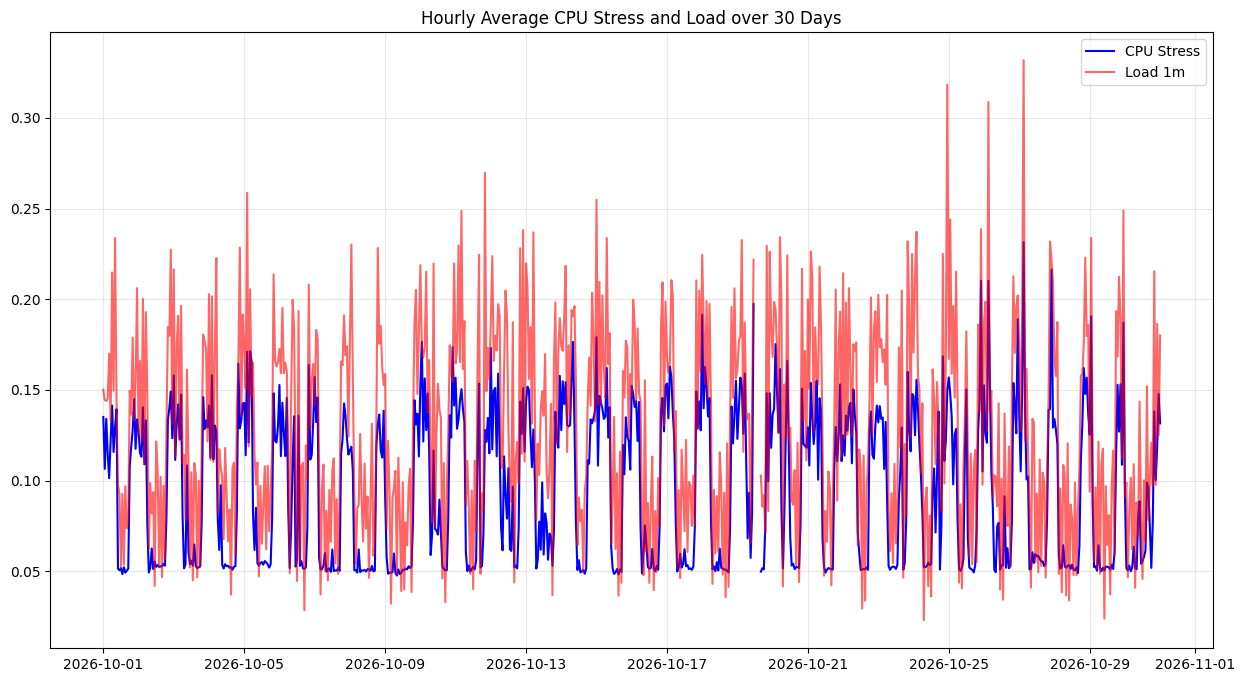

In [16]:
# --- Time Series Trends (Hourly Averages) ---
# Filter for numeric columns only to avoid errors with 'day_name'
df_numeric = df.set_index('datetime').select_dtypes(include=['number'])
df_hourly = df_numeric.resample('H').mean()

plt.figure(figsize=(15, 8))
plt.plot(df_hourly.index, df_hourly['overall_cpu_stress'], label='CPU Stress', color='blue')
plt.plot(df_hourly.index, df_hourly['load-1m'], label='Load 1m', color='red', alpha=0.6)
plt.title('Hourly Average CPU Stress and Load over 30 Days')
plt.legend()
plt.grid(True, alpha=0.3) # Added a grid for better readability
plt.savefig('timeseries_cpu_load.png')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85749 entries, 0 to 85748
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            85749 non-null  int64         
 1   cpu-user             85749 non-null  float64       
 2   cpu-system           85749 non-null  float64       
 3   cpu-iowait           85749 non-null  float64       
 4   sys-mem-available    85749 non-null  int64         
 5   sys-mem-total        85749 non-null  int64         
 6   disk-io-time         85749 non-null  float64       
 7   load-1m              85749 non-null  float64       
 8   load-5m              85749 non-null  float64       
 9   load-15m             85749 non-null  float64       
 10  disk-bytes-read      85749 non-null  float64       
 11  disk-bytes-written   85749 non-null  float64       
 12  overall_cpu_stress   85749 non-null  float64       
 13  memory_used          85749 non-

In [23]:
df[['cpu-user','cpu-system','cpu-iowait','sys-mem-available','sys-mem-total','disk-io-time','load-1m','load-5m','load-15m',
   'disk-bytes-read','disk-bytes-written','overall_cpu_stress','memory_used','memory_used_percent','disk_activity','datetime','hour','day_name','is_weekend']].to_csv('set2_cleaned_sys_data.csv',index=False)

In [24]:
from google.colab import files
files.download('set2_cleaned_sys_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>